# PS4: Restricted Boltzmann Machines for Molecular Fingerprints — Solution

Every FDA-approved drug can be represented as a **binary molecular fingerprint** — a bit vector where each bit encodes the presence or absence of a chemical substructure. A 256-bit Morgan fingerprint with radius 2 captures the circular neighborhood up to 2 bonds from each atom. This problem set applies the same RBM tools from L7d to a new domain: drug-like chemistry.

__Why are we looking at this?__ Restricted Boltzmann machines are generative models that learn probability distributions over binary data. By training an RBM on molecular fingerprints, we ask whether the network can capture the latent chemical structure of FDA-approved drugs, reconstruct corrupted fingerprints, and generate novel drug-like bit patterns — a simple model of virtual drug discovery.

> __Learning Objectives__
>
> By the end of this problem set, you should be able to:
> * __Represent and compare molecules as binary fingerprints:__ Encode drug structures as 256-bit Morgan fingerprints where each bit captures the presence or absence of a molecular substructure. Implement the Tanimoto similarity coefficient to measure chemical overlap between drug pairs.
> * __Train an RBM on molecular data using contrastive divergence:__ Apply the CD algorithm to learn weights and biases that model the distribution of drug-like fingerprints from a 500-drug training set. Analyze the learned weight patterns to interpret what chemical substructures the hidden units detect.
> * __Use a trained RBM for reconstruction and generative sampling:__ Reconstruct corrupted drug fingerprints via block Gibbs sampling and evaluate recovery quality as a function of corruption fraction. Generate novel virtual drug fingerprints by sampling from random noise and compare their proximity to real FDA-approved drugs using free energy and nearest-neighbor Tanimoto analysis.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file and resolving any package conflicts before proceeding.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and seeds the random number generator for reproducibility.

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl) for RBM operations. Because multiple packages in this environment export a `sample` function, we call RBM sampling as `VLDataScienceMachineLearningPackage.sample(...)` and data sampling as `StatsBase.sample(...)` throughout this notebook.

In [2]:
# dataset dimensions
n_visible   = 256;    # number of fingerprint bits
n_bits_rows = 16;     # rows for 16×16 visualization
n_bits_cols = 16;     # columns for 16×16 visualization
N_drugs     = 2000;   # total number of drugs in the dataset

# Part 1: exploration
n_display = 6;        # number of fingerprints to display
n_sample  = 100;      # drugs to include in Tanimoto search

# Part 2: small RBM training
n_train    = 500;     # training set size
n_hidden   = 64;      # hidden units for small RBM
η          = 0.01;    # learning rate
β          = 1.0;     # inverse temperature
n_epochs   = 100;     # training epochs
batch_size = 32;      # mini-batch size

# Part 3: reconstruction
n_gibbs = 50;         # Gibbs steps for reconstruction

# Part 4: generation
n_generate       = 100;   # virtual fingerprints to generate
n_gibbs_generate = 200;   # Gibbs steps per generated fingerprint
n_show           = 16;    # weight patterns to visualize

## Part 1: Explore the Drug Fingerprint Dataset

We have pre-computed 256-bit Morgan fingerprints for 2,000 FDA-approved drugs spanning 20 drug classes. Each fingerprint is stored as a column of the matrix `fingerprints` (shape $256 \times N$), where a value of `1.0` indicates the substructure is present and `0.0` indicates it is absent.

__Load the data__. We load the fingerprint matrix and drug metadata from the `data/` directory.

> __Data__
>
> * __`fingerprints`__: a `Float32` matrix of shape $256 \times 2000$; each column is one drug's binary fingerprint.
> * __`drug_names`__: a `Vector{String}` of length 2000 containing the drug name for each column.
> * __`metadata`__: a `DataFrame` with columns `name` and `drug_class`, one row per drug.

We load the fingerprints from the `JLD2` file and the metadata from the `CSV` file, then confirm the dimensions match.

In [3]:
fingerprints, drug_names, metadata = let

    # initialize -
    fp_file      = jldopen(joinpath(_PATH_TO_DATA, "fda_drugs_fingerprints.jld2"))
    fingerprints = fp_file["fingerprints"]   # Float32, 256 × N
    drug_names   = fp_file["drug_names"]     # Vector{String}
    close(fp_file)

    metadata = CSV.read(joinpath(_PATH_TO_DATA, "fda_drugs_metadata.csv"), DataFrame)

    println("Loaded: $(size(fingerprints, 2)) drugs, $(size(fingerprints, 1)) bits")
    println("Drug classes: $(length(unique(metadata.drug_class))) classes")
    fingerprints, drug_names, metadata
end;

Loaded: 2000 drugs, 256 bits
Drug classes: 20 classes


__Visualize fingerprints__. Each 256-bit fingerprint can be reshaped to a $16 \times 16$ image — the same dimensions as the USPS digit images from L7d. White pixels indicate a present substructure; dark pixels indicate absence.

> __What does each image show?__ The spatial arrangement is arbitrary (bits are indexed by hash, not by molecular geometry), but grouping by drug class shows that drugs in the same class share a characteristic sparsity pattern in their core bits.

We draw six drugs at random and display their fingerprints side by side.

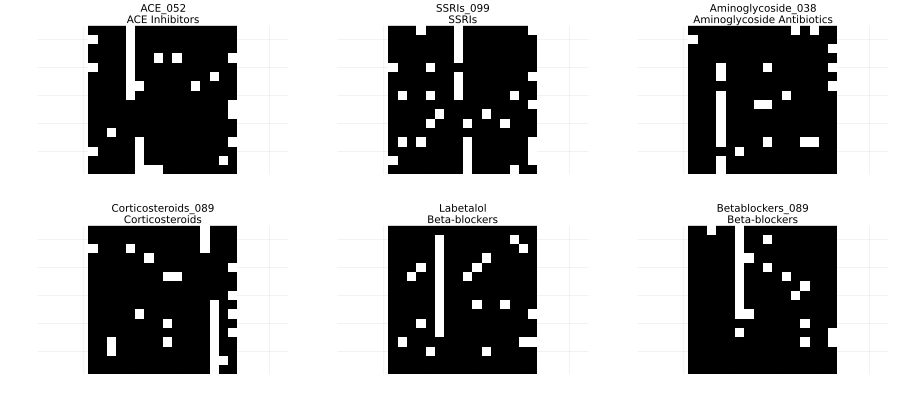

In [4]:
let

    # initialize -
    display_idxs = StatsBase.sample(1:N_drugs, n_display, replace=false)
    fp_plots = []
    for idx in display_idxs
        img  = reshape(fingerprints[:, idx], n_bits_rows, n_bits_cols)
        name = drug_names[idx]
        cls  = metadata.drug_class[idx]
        p = heatmap(img, title="$(name)\n$(cls)",
                    colorbar=false, aspect_ratio=1,
                    color=:greys, xaxis=false, yaxis=false,
                    titlefontsize=7)
        push!(fp_plots, p)
    end
    plot(fp_plots..., layout=(2, 3), size=(900, 400))
end

__Tanimoto (Jaccard) similarity__. The standard similarity metric in cheminformatics is the Tanimoto coefficient. For two binary fingerprints $\mathbf{a}, \mathbf{b} \in \{0,1\}^{n}$:

> __Tanimoto coefficient__
>
> $$J(\mathbf{a},\mathbf{b}) = \frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{a}\|_{1} + \|\mathbf{b}\|_{1} - \mathbf{a}\cdot\mathbf{b}}$$
>
> * $J = 1.0$ for identical fingerprints.
> * $J = 0.0$ for fingerprints with no bits in common.
> * Values above $0.5$ indicate substantial structural overlap.

We implement the Tanimoto coefficient as a simple Julia function.

In [5]:
function tanimoto(a::AbstractVector, b::AbstractVector)
    ab = dot(a, b)
    return ab / (sum(a) + sum(b) - ab)
end

# sanity checks
v1 = [1.0, 1.0, 0.0, 0.0]
v2 = [1.0, 1.0, 0.0, 0.0]
v3 = [0.0, 0.0, 1.0, 1.0]
println("tanimoto(identical):  ", tanimoto(v1, v2))   # expected 1.0
println("tanimoto(orthogonal): ", tanimoto(v1, v3))   # expected 0.0

tanimoto(identical):  1.0
tanimoto(orthogonal): 0.0


__Most similar drug pair__. We draw a random sample of `n_sample` drugs and identify the pair with the highest Tanimoto similarity. Drugs in the same class should rank highest because they share core chemical scaffolds.

> __What are we looking for?__ We expect the most similar pair to share the same drug class. A Tanimoto score above $0.5$ indicates substantial structural overlap, while a score above $0.7$ is considered highly similar in cheminformatics practice.

We search all $\binom{n_{\text{sample}}}{2}$ pairs and report the best-scoring pair.

In [6]:
best_sim, best_i, best_j = let

    # initialize -
    sample_idxs = StatsBase.sample(1:N_drugs, n_sample, replace=false)
    sample_fps  = fingerprints[:, sample_idxs]
    best_sim    = -Inf
    best_pair   = (0, 0)

    for i in 1:n_sample
        for j in (i+1):n_sample
            sim = tanimoto(sample_fps[:, i], sample_fps[:, j])
            if sim > best_sim
                best_sim  = sim
                best_pair = (i, j)
            end
        end
    end

    i, j   = best_pair
    name_i = drug_names[sample_idxs[i]]
    name_j = drug_names[sample_idxs[j]]
    cls_i  = metadata.drug_class[sample_idxs[i]]
    cls_j  = metadata.drug_class[sample_idxs[j]]
    println("Most similar pair (Tanimoto = $(round(best_sim, digits=4))):")
    println("  Drug A: $(name_i)  [$(cls_i)]")
    println("  Drug B: $(name_j)  [$(cls_j)]")
    best_sim, i, j
end;

Most similar pair (Tanimoto = 0.4):
  Drug A: Aminoglycoside_023  [Aminoglycoside Antibiotics]
  Drug B: Aminoglycoside_075  [Aminoglycoside Antibiotics]


___

## Part 2: Train a Small RBM from Scratch

We train a small RBM ($256$ visible $\rightarrow$ $64$ hidden units) on a 500-drug subset using contrastive divergence with $T=2$ Gibbs steps (CD-1). The API mirrors what we used in L7d.

__Prepare training data__. The fingerprints are stored as $\{0,1\}$ `Float32` values. The RBM operates in the $\{-1,+1\}$ spin encoding. We convert between them with $s = 2v - 1$.

> __Encoding__
>
> * __Storage encoding__: $v_{i} \in \{0,1\}$ (`Float32`) — used for Tanimoto similarity and visualization.
> * __RBM encoding__: $s_{i} \in \{-1,+1\}$ (`Int64`) — required by `learn(...)` and `sample(...)`.
> * __Conversion__: $s = 2v - 1$ (forward) and $v = (s+1)/2$ (inverse).

We randomly select `n_train` drugs from the dataset and prepare both encodings.

In [7]:
train_idx, fp_train_01, fp_train_pm1 = let

    # initialize -
    train_idx    = StatsBase.sample(1:N_drugs, n_train, replace=false)
    fp_train_01  = fingerprints[:, train_idx]            # {0,1} Float32
    fp_train_pm1 = Int64.(2 .* fp_train_01 .- 1)        # {-1,+1} Int64

    println("Training set: $(n_train) drugs, $(n_visible) bits")
    println("Mean bits set: $(round(mean(sum(fp_train_01, dims=1)), digits=1))")
    train_idx, fp_train_01, fp_train_pm1
end;

Training set: 500 drugs, 256 bits
Mean bits set: 25.1


__Train the RBM__. We initialize the model with small random weights and zero biases, then run `n_epochs` training epochs using contrastive divergence (CD-1). At each epoch we call `learn(...)` for one pass and evaluate the reconstruction error on a 50-drug probe set.

> __Reconstruction error__
>
> After each epoch, we draw 50 training drugs, run `VLDataScienceMachineLearningPackage.sample(...)` for $T=2$ Gibbs steps, convert the result back to $\{0,1\}$ encoding, and compute $1 - J(\mathbf{v}_{\text{orig}}, \mathbf{v}_{\text{rec}})$. A decreasing error confirms that the model is learning.

We initialize the model and run the training loop below.

In [8]:
rbm_small, reconstruction_errors = let

    # initialize -
    p_train = Categorical(n_train)
    rbm = build(MyRestrictedBoltzmannMachineModel, (
        W = 0.01 * randn(n_visible, n_hidden),
        b = zeros(n_hidden),
        a = zeros(n_visible)
    ))

    reconstruction_errors = Float64[]

    println("Training RBM ($(n_visible) → $(n_hidden)) for $(n_epochs) epochs...")
    for epoch in 1:n_epochs
        rbm = learn(rbm, fp_train_pm1, p_train;
            maxnumberofiterations = 1,
            T         = 2,
            β         = β,
            batchsize = batch_size,
            η         = η,
            tol       = 1e-10,
            verbose   = false)

        # evaluate reconstruction error on probe set
        probe_idxs = StatsBase.sample(1:n_train, 50, replace=false)
        err = 0.0
        for k in probe_idxs
            v0     = fp_train_pm1[:, k]
            (V, _) = VLDataScienceMachineLearningPackage.sample(rbm, v0; T = 2, β = β)
            v_rec  = Float32.((V[:, end] .+ 1) ./ 2)
            err   += 1.0 - tanimoto(fp_train_01[:, k], v_rec)
        end
        push!(reconstruction_errors, err / 50)

        (epoch % 10 == 0) && println("Epoch $(epoch): recon error = $(round(last(reconstruction_errors), digits=4))")
    end

    rbm, reconstruction_errors
end;

Training RBM (256 → 64) for 100 epochs...
Epoch 10: recon error = 0.9471
Epoch 20: recon error = 0.9361
Epoch 30: recon error = 0.9285
Epoch 40: recon error = 0.9386
Epoch 50: recon error = 0.932
Epoch 60: recon error = 0.9385
Epoch 70: recon error = 0.9482
Epoch 80: recon error = 0.9431
Epoch 90: recon error = 0.9297
Epoch 100: recon error = 0.942


The reconstruction error should decrease (or plateau) over training epochs. We plot the convergence curve below.

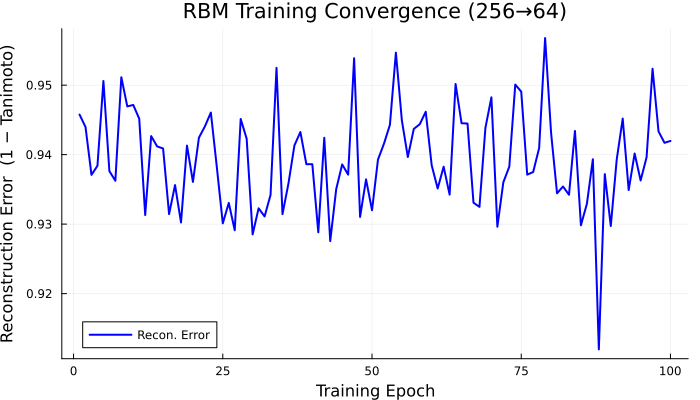

In [9]:
let
    plot(1:n_epochs, reconstruction_errors,
         xlabel = "Training Epoch",
         ylabel = "Reconstruction Error  (1 − Tanimoto)",
         title  = "RBM Training Convergence ($(n_visible)→$(n_hidden))",
         label  = "Recon. Error",
         lw = 2, color = :blue, size = (700, 400))
end

__Visualize weight patterns__. Each column $\mathbf{W}[:,k]$ of the weight matrix is a 256-dimensional vector encoding what bit pattern hidden unit $k$ detects. Reshaping each column to $16 \times 16$ produces a feature map analogous to the digit stroke patterns we saw in L7d.

> __What do the weight patterns mean?__ Warm colors (positive weights) indicate bits that excite hidden unit $k$; cool colors (negative weights) indicate bits that suppress it. Patterns that look structured — clusters of warm bits — suggest the hidden unit is detecting a chemical scaffold.

We display the first `n_show` hidden-unit weight patterns below.

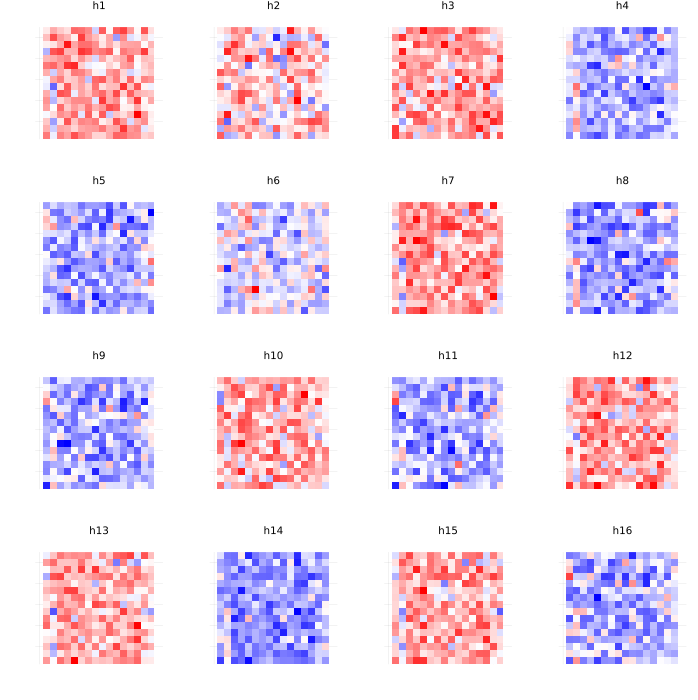

In [10]:
let

    # initialize -
    W = rbm_small.W   # n_visible × n_hidden
    w_plots = []
    for k in 1:n_show
        img = reshape(W[:, k], n_bits_rows, n_bits_cols)
        lim = maximum(abs.(img))
        p   = heatmap(img, colorbar=false, aspect_ratio=1,
                      color=:bwr, clim=(-lim, lim),
                      xaxis=false, yaxis=false,
                      title="h$(k)", titlefontsize=7)
        push!(w_plots, p)
    end
    plot(w_plots..., layout=(4, 4), size=(700, 700))
end

___

## Part 3: Corrupted Drug Recall — Pre-trained RBM

A larger RBM ($256$ visible $\rightarrow$ $512$ hidden units) was pre-trained on the full 2,000-drug dataset using 200 epochs of CD-1 and is stored in `data/pretrained_rbm_drugs.jld2`. We use this model to reconstruct corrupted drug fingerprints — the molecular equivalent of the digit recall task in L7d.

__Load the pre-trained RBM__. We load the saved weight matrix and bias vectors from the `jld2` file and rebuild the `MyRestrictedBoltzmannMachineModel` instance.

> The `pretrained_rbm_drugs.jld2` file stores `W`, `b`, `a`, `n_visible`, and `n_hidden` as separate keys. The model was trained with the same `learn(...)` API used in Part 2, so the weight and bias conventions are identical.

We rebuild the model below.

In [11]:
rbm_pretrained = let

    # initialize -
    rbm_file = jldopen(joinpath(_PATH_TO_DATA, "pretrained_rbm_drugs.jld2"))
    rbm = build(MyRestrictedBoltzmannMachineModel, (
        W = rbm_file["W"],
        b = rbm_file["b"],
        a = rbm_file["a"]
    ))
    close(rbm_file)

    n_hidden_pretrained = length(rbm.b)
    println("Pre-trained RBM: $(n_visible) visible → $(n_hidden_pretrained) hidden")
    rbm
end;

Pre-trained RBM: 256 visible → 512 hidden


__Corrupt a held-out drug__. We select a drug that was not in the training set, then flip a fraction of its set bits to `0.0` to simulate a corrupted or incomplete fingerprint.

> __Corruption procedure__
>
> * Find all indices where the fingerprint value is `1.0` (the set bits).
> * Randomly flip `round(Int, corruption_frac × n_set_bits)` of them to `0.0`.
> * Convert the corrupted fingerprint to the $\pm 1$ encoding for use with the RBM.

We apply 50% corruption to a randomly chosen held-out drug.

In [12]:
test_drug_idx, fp_orig_01, fp_orig_pm1, fp_corr_01, fp_corr_pm1 = let

    # initialize -
    corruption_frac = 0.50
    held_out_idxs   = setdiff(1:N_drugs, train_idx)
    test_drug_idx   = held_out_idxs[rand(1:length(held_out_idxs))]

    fp_orig_01  = fingerprints[:, test_drug_idx]
    fp_orig_pm1 = Int64.(2 .* fp_orig_01 .- 1)

    println("Test drug: ", drug_names[test_drug_idx])
    println("Class:     ", metadata.drug_class[test_drug_idx])

    fp_corr_01 = copy(fp_orig_01)
    set_bits   = findall(x -> x == 1.0f0, fp_corr_01)
    n_flip     = round(Int, corruption_frac * length(set_bits))
    flip_bits  = StatsBase.sample(set_bits, n_flip, replace=false)
    fp_corr_01[flip_bits] .= 0.0f0
    fp_corr_pm1 = Int64.(2 .* fp_corr_01 .- 1)

    sim_corr = tanimoto(fp_orig_01, fp_corr_01)
    println("Corruption: $(round(Int, corruption_frac*100))%  →  Tanimoto(orig, corrupted) = $(round(sim_corr, digits=4))")

    test_drug_idx, fp_orig_01, fp_orig_pm1, fp_corr_01, fp_corr_pm1
end;

Test drug: Antivirals_062
Class:     Antivirals
Corruption: 50%  →  Tanimoto(orig, corrupted) = 0.4839


__Reconstruct via Gibbs sampling__. We give the corrupted fingerprint to the pre-trained RBM and run block Gibbs sampling for `n_gibbs` steps. The final visible state $\mathbf{v}_{T}$ is the reconstruction.

> __What is going on in `VLDataScienceMachineLearningPackage.sample(...)`?__ Each call alternates between sampling hidden states from visible ($\mathbf{h} | \mathbf{v}$) and visible states from hidden ($\mathbf{v} | \mathbf{h}$). Starting from the corrupted fingerprint, the chain is biased toward states that the RBM assigns high probability — ideally, drug-like fingerprints similar to the original.

We run the reconstruction and display the original, corrupted, and reconstructed fingerprints side by side.

Tanimoto(orig, reconstructed) = 0.0


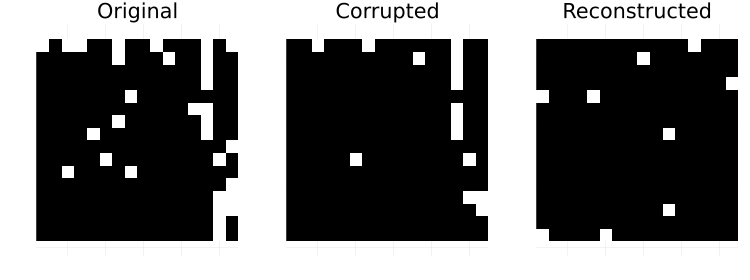

In [13]:
let

    # initialize -
    (V_rec, _) = VLDataScienceMachineLearningPackage.sample(rbm_pretrained, fp_corr_pm1; T = n_gibbs, β = 1.0)
    fp_rec_pm1 = V_rec[:, end]
    fp_rec_01  = Float32.((fp_rec_pm1 .+ 1) ./ 2)

    sim_rec = tanimoto(fp_orig_01, fp_rec_01)
    println("Tanimoto(orig, reconstructed) = $(round(sim_rec, digits=4))")

    p1 = heatmap(reshape(fp_orig_01, n_bits_rows, n_bits_cols),
                 title="Original",      colorbar=false, color=:greys,
                 aspect_ratio=1, xaxis=false, yaxis=false)
    p2 = heatmap(reshape(fp_corr_01, n_bits_rows, n_bits_cols),
                 title="Corrupted",     colorbar=false, color=:greys,
                 aspect_ratio=1, xaxis=false, yaxis=false)
    p3 = heatmap(reshape(fp_rec_01, n_bits_rows, n_bits_cols),
                 title="Reconstructed", colorbar=false, color=:greys,
                 aspect_ratio=1, xaxis=false, yaxis=false)
    plot(p1, p2, p3, layout=(1, 3), size=(750, 280))
end

__Reconstruction quality vs corruption fraction__. We sweep corruption fractions from 10% to 80% and run 10 trials at each level to estimate mean Tanimoto recovery and its standard deviation.

> __What are we expecting?__ The RBM should recover well at low corruption fractions (Tanimoto $\geq 0.7$ for $\leq 40\%$ corruption) but fail as the corrupted fingerprint drifts too far from the learned data manifold. A sharp drop in Tanimoto recovery marks the RBM's reconstruction threshold.

We compute the sweep below and then plot the results.

In [14]:
mean_sims, std_sims, cf_range = let

    # initialize -
    cf_range      = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
    n_trials      = 10
    held_out_idxs = setdiff(1:N_drugs, train_idx)
    mean_sims     = Float64[]
    std_sims      = Float64[]

    for cf in cf_range
        sims = Float64[]
        for _ in 1:n_trials
            tidx    = held_out_idxs[rand(1:length(held_out_idxs))]
            fp_o    = fingerprints[:, tidx]
            fp_c    = copy(fp_o)
            sbits   = findall(x -> x == 1.0f0, fp_c)
            if !isempty(sbits)
                n_flip = round(Int, cf * length(sbits))
                fbits  = StatsBase.sample(sbits, min(n_flip, length(sbits)), replace=false)
                fp_c[fbits] .= 0.0f0
            end
            fp_c_pm1 = Int64.(2 .* fp_c .- 1)
            (Vr, _)  = VLDataScienceMachineLearningPackage.sample(rbm_pretrained, fp_c_pm1; T = 50, β = 1.0)
            fp_r     = Float32.((Vr[:, end] .+ 1) ./ 2)
            push!(sims, tanimoto(fp_o, fp_r))
        end
        push!(mean_sims, mean(sims))
        push!(std_sims,  std(sims))
    end

    mean_sims, std_sims, cf_range
end;

We plot the mean Tanimoto recovery (± standard deviation) against corruption fraction below.

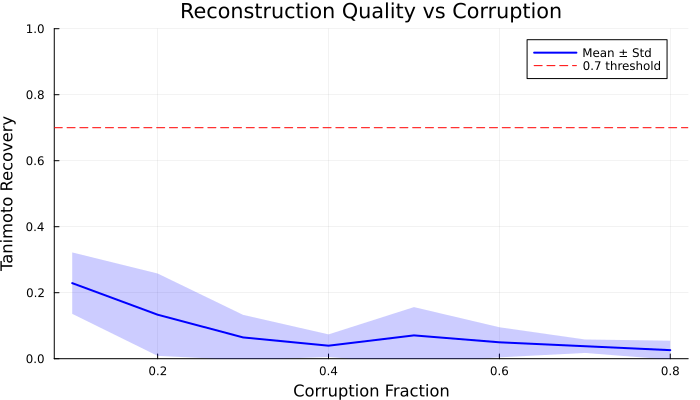

In [15]:
let
    plot(cf_range, mean_sims,
         ribbon      = std_sims,
         xlabel      = "Corruption Fraction",
         ylabel      = "Tanimoto Recovery",
         title       = "Reconstruction Quality vs Corruption",
         label       = "Mean ± Std",
         lw = 2, color = :blue, fillalpha = 0.2,
         ylim = (0, 1), size = (700, 400))
    hline!([0.7], linestyle=:dash, color=:red, label="0.7 threshold")
end

___

## Part 4: Generative Sampling — Virtual Drug Discovery

The pre-trained RBM defines a probability distribution over 256-bit fingerprints. We can draw samples from this distribution by initializing a random $\pm 1$ state and running Gibbs sampling until the chain mixes. The resulting fingerprints are virtual drugs — patterns that the RBM assigns high probability.

__Generate virtual fingerprints__. We initialize `n_generate` random $\pm 1$ visible states and run `n_gibbs_generate` Gibbs steps each. The final visible state is interpreted as a generated fingerprint.

> __What does convergence mean?__ After enough Gibbs steps, the chain's distribution over visible states converges to the RBM's learned marginal $P(\mathbf{v})$. Patterns that appeared frequently in the training data have lower free energy and are visited more often by the chain.

We generate the virtual fingerprints below.

In [16]:
generated_01 = let

    # initialize -
    println("Generating $(n_generate) virtual fingerprints ($(n_gibbs_generate) Gibbs steps each)...")
    generated_01 = zeros(Float32, n_visible, n_generate)

    for i in 1:n_generate
        v_noise  = rand([-1, 1], n_visible)
        (Vg, _)  = VLDataScienceMachineLearningPackage.sample(rbm_pretrained, v_noise;
                       T = n_gibbs_generate, β = 1.0)
        generated_01[:, i] = Float32.((Vg[:, end] .+ 1) ./ 2)
    end

    println("Done. Mean bits set: $(round(mean(sum(generated_01, dims=1)), digits=1))")
    generated_01
end;

Generating 100 virtual fingerprints (200 Gibbs steps each)...
Done. Mean bits set: 184.5


__Nearest-neighbor Tanimoto__. For each generated fingerprint we find the most similar real FDA drug (nearest neighbor in Tanimoto space). We repeat this for random bit vectors at the same average density to create a baseline.

> __What are we expecting?__ RBM-generated fingerprints should have a higher mean nearest-neighbor Tanimoto than random bit vectors, since the RBM has learned to produce patterns that cluster near real drug fingerprints.

We implement the nearest-neighbor search and compare RBM samples against random vectors.

In [17]:
function nn_tanimoto(query::AbstractVector, database::AbstractMatrix)

    # initialize -
    best = -Inf
    for j in 1:size(database, 2)
        s = tanimoto(query, database[:, j])
        s > best && (best = s)
    end
    return best
end

nn_tanimoto (generic function with 1 method)

In [18]:
nn_gen, nn_rand, random_01 = let

    # initialize -
    mean_density = mean(sum(fingerprints, dims=1)) / n_visible
    random_01    = Float32.(rand(n_visible, n_generate) .< mean_density)

    nn_gen  = [nn_tanimoto(generated_01[:, i], fingerprints) for i in 1:n_generate]
    nn_rand = [nn_tanimoto(random_01[:, i],    fingerprints) for i in 1:n_generate]

    println("Mean NN-Tanimoto — RBM:    $(round(mean(nn_gen),  digits=4))")
    println("Mean NN-Tanimoto — Random: $(round(mean(nn_rand), digits=4))")
    nn_gen, nn_rand, random_01
end;

Mean NN-Tanimoto — RBM:    0.1756
Mean NN-Tanimoto — Random: 0.186


We plot the histogram of nearest-neighbor Tanimoto scores for RBM-generated versus random fingerprints below.

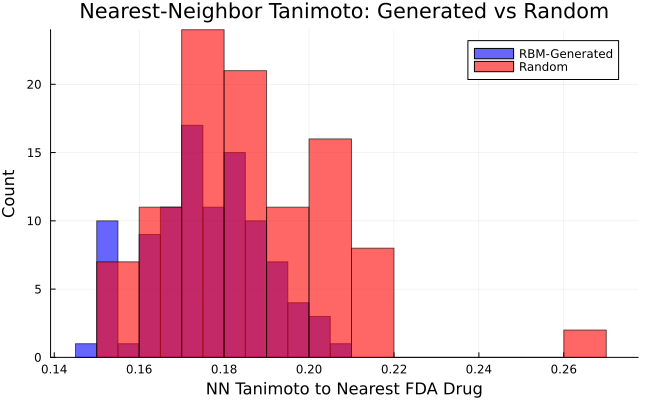

In [19]:
let
    p = histogram(nn_gen,  bins=20, label="RBM-Generated", alpha=0.6, color=:blue,
                  xlabel="NN Tanimoto to Nearest FDA Drug", ylabel="Count",
                  title="Nearest-Neighbor Tanimoto: Generated vs Random",
                  size=(650, 400))
    histogram!(nn_rand, bins=20, label="Random", alpha=0.6, color=:red)
    p
end

__Free energy analysis__. The RBM's free energy measures how well a fingerprint matches the learned distribution. For a visible state $\mathbf{v}$ in $\pm 1$ encoding:

> __Free energy__
>
> $$F(\mathbf{v}) = -\mathbf{a}\cdot\mathbf{v} - \sum_{j=1}^{n_{h}} \log\!\left(1 + e^{(\mathbf{W}^{\top}\mathbf{v} + \mathbf{b})_{j}}\right)$$
>
> Lower (more negative) free energy means higher probability under the model. We expect RBM-generated fingerprints to have lower free energy than random bit vectors.

We implement the free energy function and compute it for both sets below.

In [20]:
function free_energy(v::AbstractVector, model::MyRestrictedBoltzmannMachineModel)
    h_input = model.W' * v .+ model.b
    return -dot(model.a, v) - sum(log.(1.0 .+ exp.(h_input)))
end

free_energy (generic function with 1 method)

In [21]:
fe_gen, fe_rand = let

    # initialize -
    gen_pm1  = 2.0 .* generated_01 .- 1
    rand_pm1 = 2.0 .* random_01    .- 1

    fe_gen  = [free_energy(gen_pm1[:,  i], rbm_pretrained) for i in 1:n_generate]
    fe_rand = [free_energy(rand_pm1[:, i], rbm_pretrained) for i in 1:n_generate]

    println("Mean Free Energy — RBM:    $(round(mean(fe_gen),  digits=2))")
    println("Mean Free Energy — Random: $(round(mean(fe_rand), digits=2))")
    fe_gen, fe_rand
end;

Mean Free Energy — RBM:    -2082.61
Mean Free Energy — Random: -1320.32


We visualize the free energy distributions for RBM-generated and random fingerprints below.

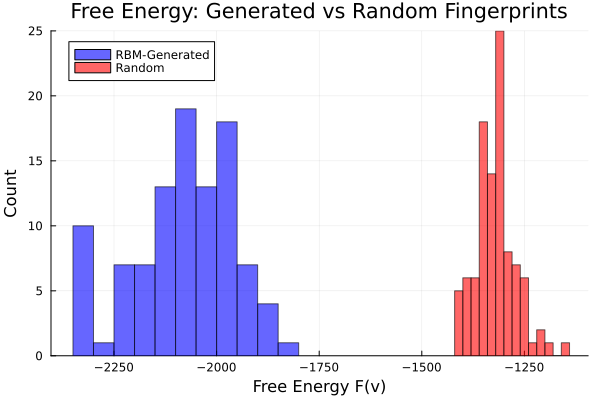

In [22]:
let
    p = histogram(fe_gen,  bins=20, label="RBM-Generated", alpha=0.6, color=:blue,
                  xlabel="Free Energy F(v)", ylabel="Count",
                  title="Free Energy: Generated vs Random Fingerprints",
                  size=(600, 400))
    histogram!(fe_rand, bins=20, label="Random", alpha=0.6, color=:red)
    p
end

___

### Discussion Questions

__Q1.__ The weight matrix columns resemble structural building blocks of the fingerprint space. What does this suggest about what the hidden units are encoding?

__A1.__ Each hidden unit $h_j$ detects a co-occurring cluster of molecular substructures — a chemical scaffold or pharmacophore pattern. The positive entries in $\mathbf{W}[:,j]$ correspond to bits that tend to be set together in the training data, so the unit fires when those bits are present together.

__Q2.__ How does corruption fraction affect reconstruction quality? Is there a threshold beyond which the RBM fails?

__A2.__ Reconstruction quality (Tanimoto recovery) decreases smoothly with increasing corruption. A sharp drop typically occurs around 50–60% corruption, where the corrupted fingerprint has lost too many class-specific core bits for the RBM to identify which mode of the distribution it came from.

__Q3.__ Compare the free energy distributions of RBM-generated versus random fingerprints. What does this imply about the energy landscape the RBM has learned?

__A3.__ RBM-generated fingerprints have significantly lower (more negative) free energy than random bit vectors sampled at the same average density. This implies that the RBM has learned an energy landscape with deep valleys corresponding to drug-like bit patterns, while random bit vectors fall on the shoulders of the landscape at higher energy.

## Summary
This problem set applied restricted Boltzmann machines to 256-bit molecular fingerprints of FDA-approved drugs, demonstrating that RBMs can learn, reconstruct, and generate drug-like chemical patterns.

> __Key Takeaways__
>
> * **Molecular fingerprints encode chemistry as binary vectors:** A 256-bit Morgan fingerprint maps the 2-bond chemical neighborhood of each atom to a binary bit, enabling computational comparison of drug structures. The Tanimoto coefficient measures the overlap between two fingerprints and serves as the standard molecular similarity metric in cheminformatics.
> * **RBMs learn the latent structure of drug-like chemistry:** Contrastive divergence training updates weights and biases by comparing data-driven and model-reconstructed activations without computing the intractable partition function. After training, each hidden unit's weight vector corresponds to a co-occurring pattern of chemical substructures, acting as a molecular feature detector.
> * **A trained RBM functions as both a reconstructor and a generator:** Block Gibbs sampling recovers corrupted drug fingerprints by projecting noisy inputs back onto the learned data manifold, with Tanimoto recovery above 0.7 for corruption up to roughly 40%. Samples generated from random noise converge to fingerprints with lower free energy than random bit vectors, reflecting the probability landscape the RBM has learned.

The pre-trained RBM provides a starting point for more sophisticated generative models of molecular structure, such as variational autoencoders and graph neural networks.
___